<a href="https://colab.research.google.com/github/kanaka-22/codealpha_tasks/blob/main/Task2_Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import Required Libraries***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.rcParams['figure.figsize'] = (12,6)
sns.set_style("whitegrid")

***Load Dataset***

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Unemployment in India.csv')
print(df.head())
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data colu

***Data Cleaning***

In [6]:
df.columns = df.columns.str.strip()
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Sort values
df = df.sort_values('Date')

# Handle missing values
df = df.dropna()

# Rename column if needed
df.rename(columns={'Estimated Unemployment Rate (%)': 'Rate'}, inplace=True)

print(df.head())

             Region       Date Frequency  Rate  Estimated Employed  \
0    Andhra Pradesh 2019-05-31   Monthly  3.65          11999139.0   
290       Telangana 2019-05-31   Monthly  2.23          11053353.0   
276      Tamil Nadu 2019-05-31   Monthly  0.97          15844698.0   
257       Rajasthan 2019-05-31   Monthly  4.03          15226005.0   
243          Punjab 2019-05-31   Monthly  9.17           6088547.0   

     Estimated Labour Participation Rate (%)   Area  
0                                      43.24  Rural  
290                                    61.74  Rural  
276                                    49.44  Rural  
257                                    38.52  Rural  
243                                    44.79  Rural  


/tmp/ipykernel_20279/940278438.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


***Basic Data Exploration***

In [7]:
print("Summary Statistics:")
print(df['Rate'].describe())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

Summary Statistics:
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Rate, dtype: float64
Duplicates: 0


***Trend Visualization (Overall)***

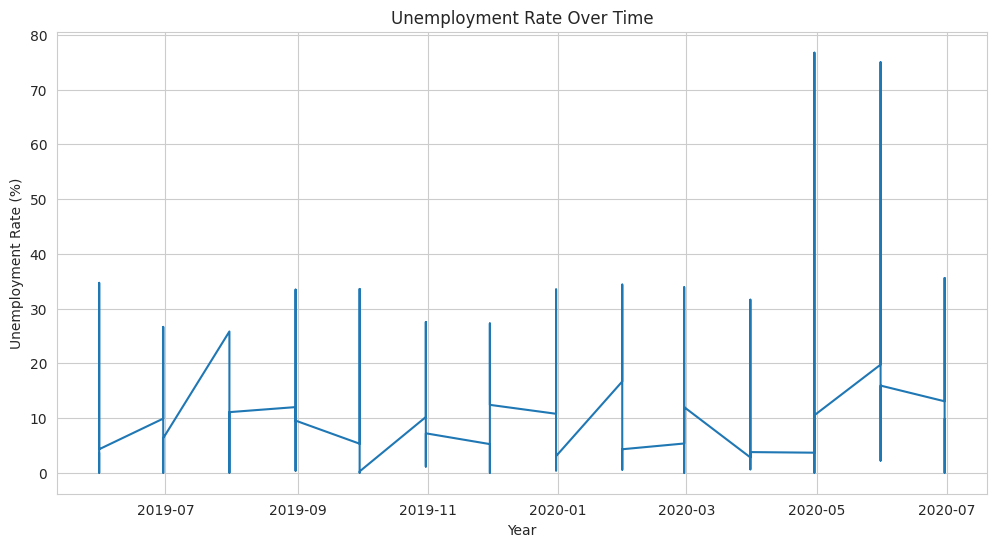

In [8]:
plt.plot(df['Date'], df['Rate'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()

***Monthly / Seasonal Pattern Analysis***

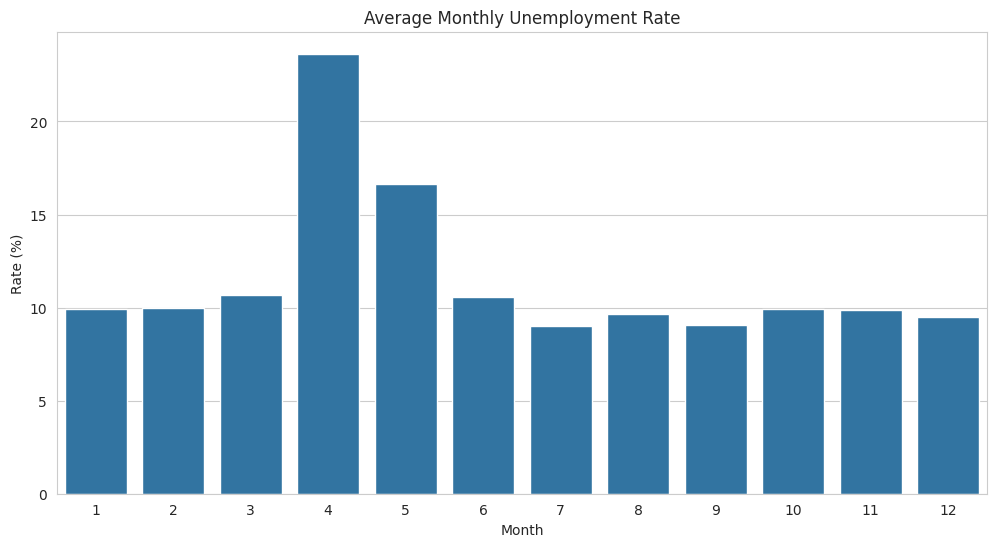

In [9]:
# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Monthly average
monthly_avg = df.groupby('Month')['Rate'].mean()

sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.show()

***Yearly Trend***

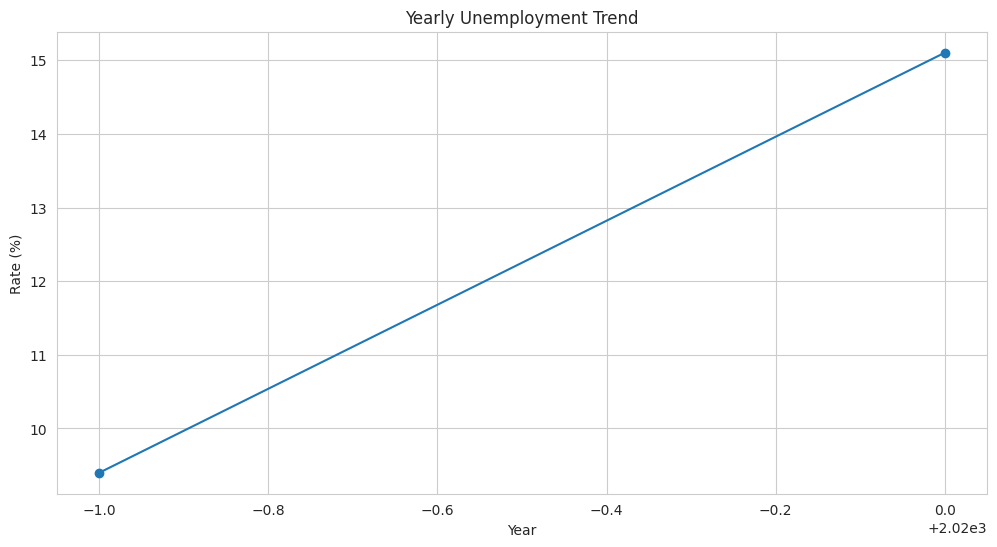

In [10]:
yearly_avg = df.groupby('Year')['Rate'].mean()

yearly_avg.plot(kind='line', marker='o')
plt.title("Yearly Unemployment Trend")
plt.ylabel("Rate (%)")
plt.show()

***COVID-19 Impact Analysis***

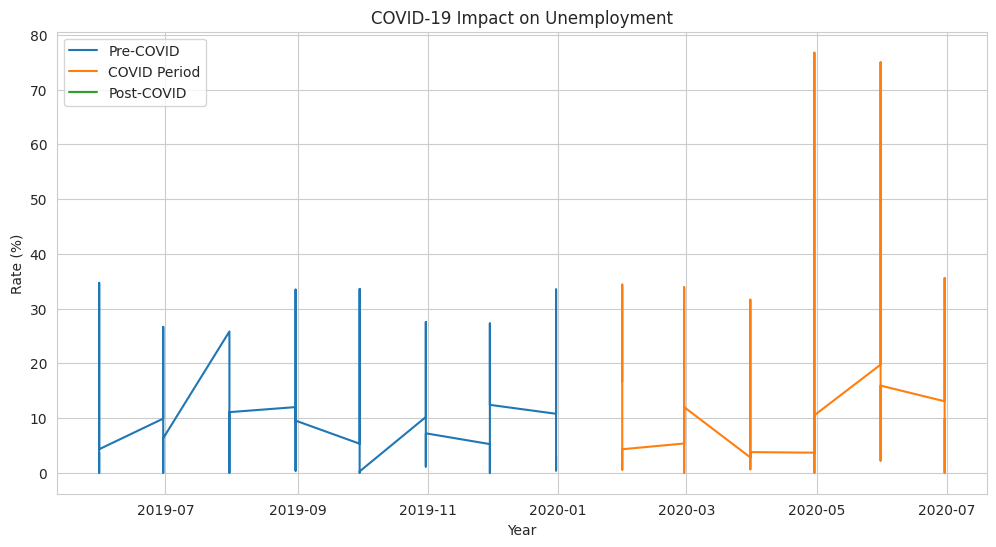

In [11]:
# Split data
pre_covid = df[df['Date'] < '2020-01-01']
covid = df[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2021-12-31')]
post_covid = df[df['Date'] > '2021-12-31']

# Plot comparison
plt.plot(pre_covid['Date'], pre_covid['Rate'], label='Pre-COVID')
plt.plot(covid['Date'], covid['Rate'], label='COVID Period')
plt.plot(post_covid['Date'], post_covid['Rate'], label='Post-COVID')

plt.legend()
plt.title("COVID-19 Impact on Unemployment")
plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.show()

***Statistical Comparison***

In [12]:
print("Pre-COVID Avg:", pre_covid['Rate'].mean())
print("COVID Avg:", covid['Rate'].mean())
print("Post-COVID Avg:", post_covid['Rate'].mean())

Pre-COVID Avg: 9.399046511627906
COVID Avg: 15.10158064516129
Post-COVID Avg: nan


***Rolling Trend (Smoothing)***

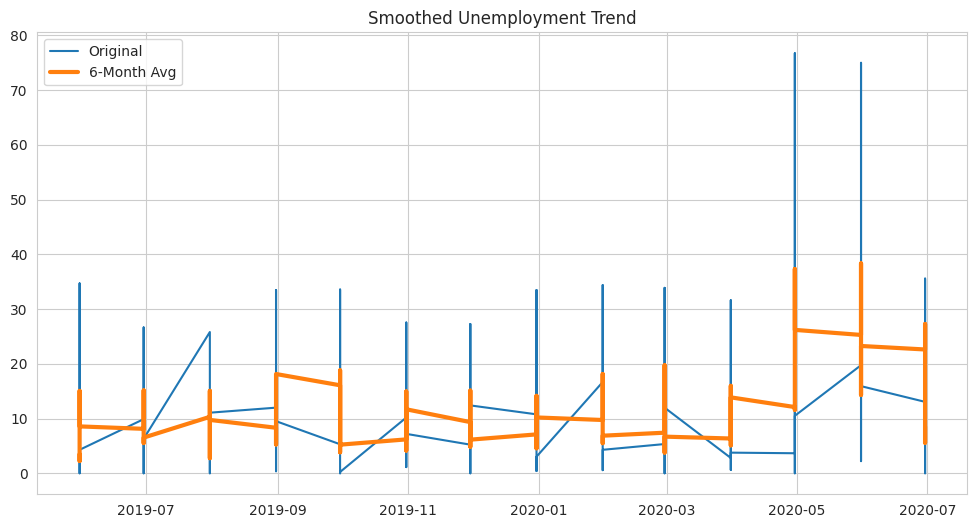

In [13]:
df['Rolling_Avg'] = df['Rate'].rolling(window=6).mean()

plt.plot(df['Date'], df['Rate'], label='Original')
plt.plot(df['Date'], df['Rolling_Avg'], label='6-Month Avg', linewidth=3)

plt.legend()
plt.title("Smoothed Unemployment Trend")
plt.show()

***Heatmap for Seasonal Trends***

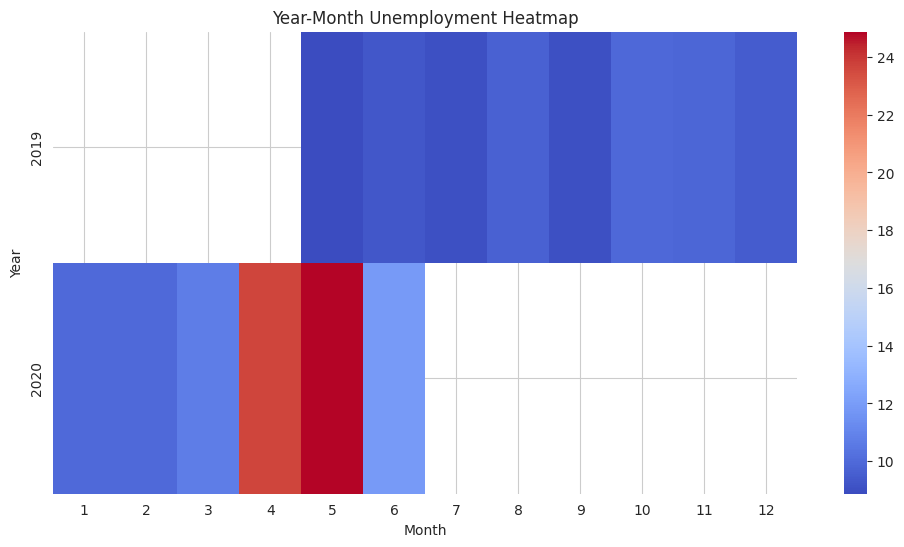

In [15]:
pivot = df.pivot_table(values='Rate', index='Year', columns='Month')

sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title("Year-Month Unemployment Heatmap")
plt.show()